# Project description

Sweet Lift Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak hours, we need to predict the amount of taxi orders for the next hour. Build a model for such a prediction.

The RMSE metric on the test set should not be more than 48.

## Project instructions

1. Download the data and resample it by one hour.
2. Analyze the data.
3. Train different models with different hyperparameters. The test sample should be 10% of the initial dataset. 
4. Test the data using the test sample and provide a conclusion.

## Data description

The data is stored in file `taxi.csv`. The number of orders is in the '*num_orders*' column.

## Preparation

In [1]:
# Importing libraries:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.ar_model import  ar_select_order
from statsmodels.tsa.ar_model import ar_select_order, AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from statsmodels.tsa.stattools import arma_order_select_ic
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
# Reading rhe CSV file:
data = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)

<AxesSubplot:xlabel='datetime'>

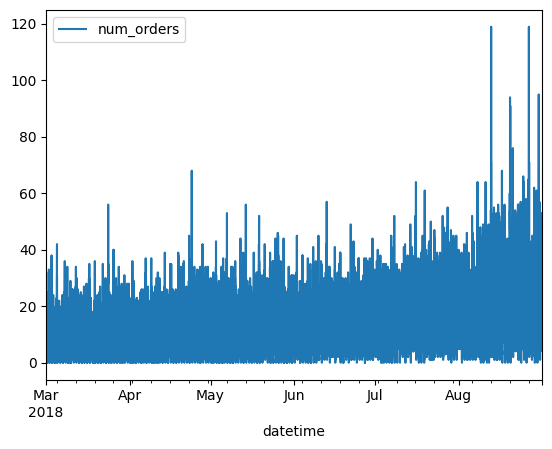

In [3]:
data.plot()

In [4]:
display(data.head())

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [6]:
data.describe()

,num_orders
count,26496.000000
mean,14.070463
std,9.211330
min,0.000000
25%,8.000000
50%,13.000000
75%,19.000000
max,119.000000


In [7]:
print(f"Start: {data.index[0]}")
print(f"End: {data.index[-1]}")
print(f"Total records: {len(data)}")

Start: 2018-03-01 00:00:00
End: 2018-08-31 23:50:00
Total records: 26496


<AxesSubplot:xlabel='datetime'>

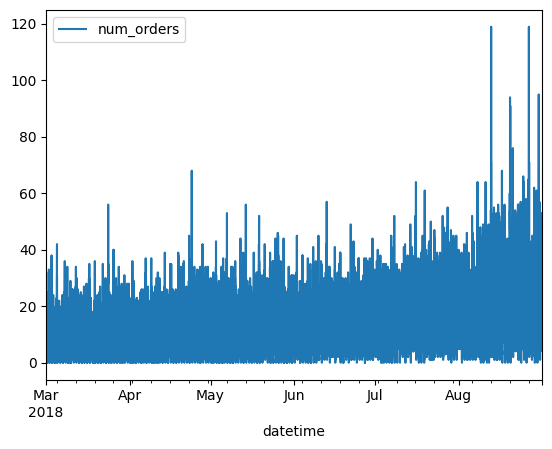

In [8]:
# Resampling data by 1 Hour:
data_hourly = data.resample('1H').sum()
data.plot()

In [9]:
# Checking Index Range for the Hourly Resampled Data:
print(f"Start: {data_hourly.index[0]}")
print(f"End: {data_hourly.index[-1]}")
print(f"Total records: {len(data_hourly)}")

Start: 2018-03-01 00:00:00
End: 2018-08-31 23:00:00
Total records: 4416


In [10]:
data_hourly.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


In [11]:
display(data_hourly.head())

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


In [12]:
data_hourly.describe()

,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


## Analysis

### Trends and Seasonability 

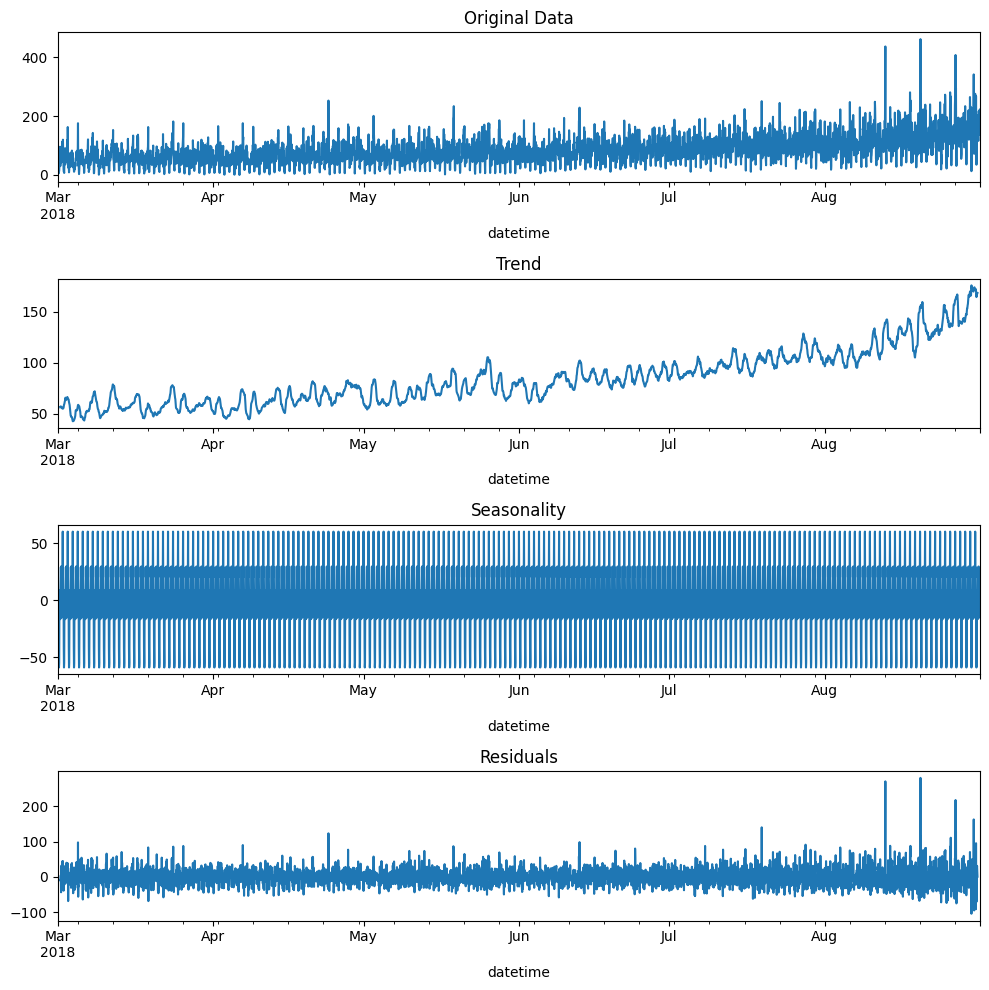

In [13]:
# plotting trends and seasonability:

decomposed = seasonal_decompose(data_hourly)

plt.figure(figsize=(10, 10))

plt.subplot(411)
decomposed.observed.plot(ax=plt.gca())
plt.title('Original Data')


plt.subplot(412)
decomposed.trend.plot(ax=plt.gca())
plt.title('Trend')

plt.subplot(413)
decomposed.seasonal.plot(ax=plt.gca())
plt.title('Seasonality')

plt.subplot(414)
decomposed.resid.plot(ax=plt.gca())
plt.title('Residuals')

plt.tight_layout()

### Making Features

#### Questions: is the year feature needed? | Dot sugested to try different rolling_mean sizes... | What should the rolling_mean size be?

In [14]:
# making features:

def make_features(data_hourly, max_lag, rolling_mean_size):
    # data_hourly['year'] = data_hourly.index.year
    data_hourly['month'] = data_hourly.index.month
    data_hourly['day'] = data_hourly.index.day
    data_hourly['dayofweek'] = data_hourly.index.dayofweek

    for lag in range(1, max_lag + 1):
        data_hourly['lag_{}'.format(lag)] = data_hourly['num_orders'].shift(lag)

    data_hourly['rolling_mean'] = (
        data_hourly['num_orders'].shift().rolling(rolling_mean_size).mean()
    )


make_features(data_hourly, 4, 12)


In [15]:
display(data_hourly.head(15))

,num_orders,month,day,dayofweek,lag_1,lag_2,lag_3,lag_4,rolling_mean
datetime,,,,,,,,,
2018-03-01 00:00:00,124,3,1,3,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,3,1,3,124.0,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,3,1,3,85.0,124.0,NaN,NaN,NaN
2018-03-01 03:00:00,66,3,1,3,71.0,85.0,124.0,NaN,NaN
2018-03-01 04:00:00,43,3,1,3,66.0,71.0,85.0,124.0,NaN
2018-03-01 05:00:00,6,3,1,3,43.0,66.0,71.0,85.0,NaN
2018-03-01 06:00:00,12,3,1,3,6.0,43.0,66.0,71.0,NaN
2018-03-01 07:00:00,15,3,1,3,12.0,6.0,43.0,66.0,NaN
2018-03-01 08:00:00,34,3,1,3,15.0,12.0,6.0,43.0,NaN


In [16]:
data_hourly.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   num_orders    4416 non-null   int64  
 1   month         4416 non-null   int64  
 2   day           4416 non-null   int64  
 3   dayofweek     4416 non-null   int64  
 4   lag_1         4415 non-null   float64
 5   lag_2         4414 non-null   float64
 6   lag_3         4413 non-null   float64
 7   lag_4         4412 non-null   float64
 8   rolling_mean  4404 non-null   float64
dtypes: float64(5), int64(4)
memory usage: 345.0 KB


In [17]:
data_hourly.describe()

,num_orders,month,day,dayofweek,lag_1,lag_2,lag_3,lag_4,rolling_mean
count,4416.000000,4416.000000,4416.000000,4416.000000,4415.000000,4414.000000,4413.000000,4412.000000,4404.000000
mean,84.422781,5.505435,15.836957,3.005435,84.395470,84.364069,84.347156,84.331369,84.308697
std,45.023853,1.713306,8.855229,1.990684,44.992356,44.949043,44.940088,44.932942,28.808040
min,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,28.166667
25%,54.000000,4.000000,8.000000,1.000000,54.000000,54.000000,54.000000,54.000000,62.916667
50%,78.000000,5.500000,16.000000,3.000000,78.000000,78.000000,78.000000,78.000000,80.500000
75%,107.000000,7.000000,23.250000,5.000000,107.000000,107.000000,107.000000,107.000000,99.833333
max,462.000000,8.000000,31.000000,6.000000,462.000000,462.000000,462.000000,462.000000,203.750000


## Training

### Spliting the Data Set

In [18]:
# Splitting the entire dataset:
train, test = train_test_split(data_hourly, shuffle=False, test_size=0.1)
train = train.dropna()

train, valid = train_test_split (train, shuffle = False, test_size=0.1)

features_train = train.drop(['num_orders'], axis=1)
target_train = train['num_orders']
features_valid = valid.drop(['num_orders'], axis=1)
target_valid = valid['num_orders']
features_test = test.drop(['num_orders'], axis=1)
target_test = test['num_orders']

print(features_train.shape)
print(features_valid.shape)
print(features_test.shape)


print(len(target_train))
print(len(target_valid))
print(len(target_test))


print(train.index.min(), train.index.max())
print(valid.index.min(), valid.index.max())
print(test.index.min(), test.index.max())


(3565, 8)
(397, 8)
(442, 8)
3565
397
442
2018-03-01 12:00:00 2018-07-28 00:00:00
2018-07-28 01:00:00 2018-08-13 13:00:00
2018-08-13 14:00:00 2018-08-31 23:00:00


### Linear Regression

In [19]:

# fitting the model:

model = LinearRegression()
model.fit(features_train, target_train)
train_predictions = model.predict(features_train)
valid_predictions = model.predict(features_valid)

# calculating rmse:

train_rmse = np.sqrt(mean_squared_error(target_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(target_valid, valid_predictions))


print("RMSE for the training set:", train_rmse)
print("RMSE for the valid set: ", test_rmse)


RMSE for the training set: 29.250001163138652
RMSE for the valid set:  40.50943331113926


#### The Autoregression ar_model performed well on the Target Valid Set. The RMSE<48. Will test on Target Test Set

### Autocorrelation Diagnostic

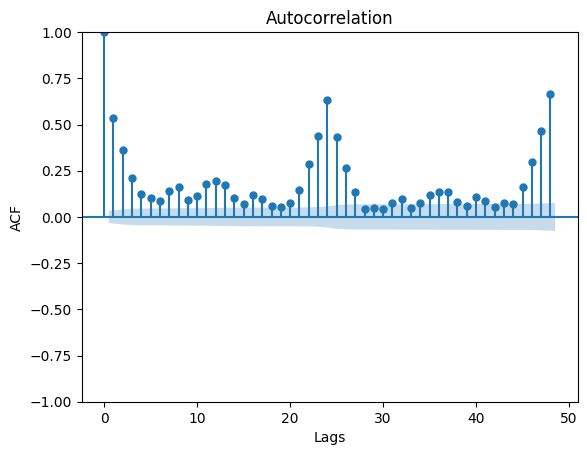

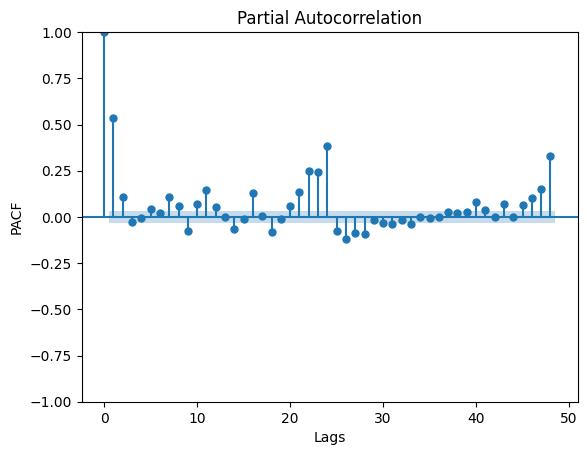

In [20]:
lags_to_check = 48
acf = plot_acf(x=target_train, lags=lags_to_check)

plt.xlabel("Lags")
plt.ylabel("ACF")
plt.show()

lags_to_check = 48
pacf = plot_pacf(x=target_train, lags=lags_to_check)

plt.xlabel("Lags")
plt.ylabel("PACF")
plt.show()

### Autoregression | ar_model

Lags that define the AR model order: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]


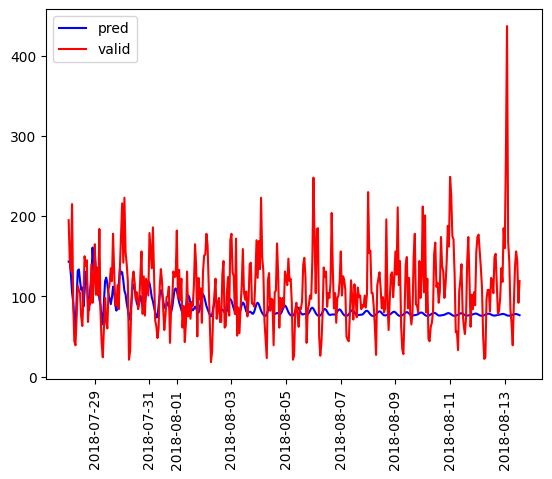

RMSE: 51.84


In [21]:

# finding optimal number of lags
mod = ar_select_order(endog=target_train, maxlag=30)  
ar_order = mod.ar_lags
print("Lags that define the AR model order:", ar_order)

# creating AR model and fit it using the training set
ar_model = AutoReg(target_train, lags=ar_order)  
ar_model = ar_model.fit()

# making predictions
start_value = len(target_train)
end_value = len(target_train) + len(target_valid) - 1
ar_pred = ar_model.predict(start=start_value, end=end_value, dynamic=False)

# plotting results
plt.plot(ar_pred, color='blue', label='pred')
plt.plot(target_valid, color='red', label='valid')  
plt.legend(loc="upper left")
plt.xticks(rotation=90)
plt.show()

ar_rmse_value = np.sqrt(mean_squared_error(target_valid, ar_pred))  
print("RMSE:",  ar_rmse_value.round(2))


#### The Autoregression ar_model did not perform well on the Target Valid Set. The RMSE>48. Will not test on Target Test Set

### ARIMA Model

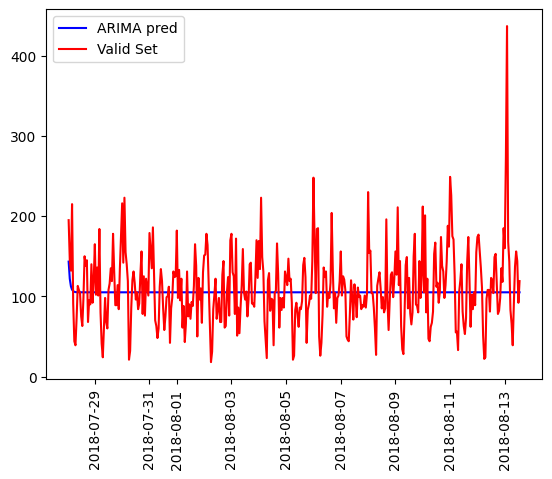

ARIMA Target Valid Set RMSE: 46.33


In [22]:
# setting AR and MA orders
ar_order = 1
diff_order = 1
ma_order = 1

arima_full_order = (ar_order, diff_order, ma_order)

# creating and fitting ARIMA model 
arima_model = ARIMA(target_train, order=arima_full_order) 
arima_model = arima_model.fit()

# making predictions
start_value = len(target_train)
end_value = len(target_train) + len(target_valid) - 1
arima_pred = arima_model.predict(start=start_value, end=end_value)


# plotting results
plt.plot(arima_pred, color='blue', label='ARIMA pred')
plt.plot(target_valid, color='red', label='Valid Set')
plt.legend(loc="upper left")
plt.xticks(rotation=90)
plt.show()

# calculating rmse
arima_rmse_value = np.sqrt(mean_squared_error(target_valid, arima_pred))
print("ARIMA Target Valid Set RMSE:", arima_rmse_value.round(2))

#### The ARIMA Model performed well on the Target Valid Set. The RMSE < 48. Will test on the Target Test Set.

### Auto_ARIMA Model

#### Because kernel kept freezing on the cell below - cell23 -, I was not able to run code for auto_arima. I will have to pick the ARIMA or the SARIMA MODEL to test for best model on the Target Test Set. @Dot suggested to make the train set smaller.

In [23]:
# Model code as per @Dot to help kernel run faster:
#model = auto_arima(target_train, 
                   #seasonal=True, 
                   #m=12, 
                   #error_action="ignore",
                   #max_p=2,        # Limit autoregressive terms
                   #max_q=2,        # Limit moving average terms  
                   #max_P=2,        # Limit seasonal AR terms
                   #max_Q=2,        # Limit seasonal MA terms
                   #max_d=1,        # Limit differencing
                   #max_D=1,        # Limit seasonal differencing
                  #stepwise=True,  # Use stepwise search (faster)
                  #suppress_warnings=True)

In [24]:
#predictions = model.predict(len(target_valid))

In [25]:
# creating a new column to store predictions
#x = np.zeros(len(data_hourly))

In [26]:
# filling training set points with NaN
#x[:len(target_train)] = np.nan 

In [27]:
# fill test set points with model predictions
#x[len(target_valid):] = predictions

In [28]:
# add new column to dataframe
#data['predicted_sales'] = x 

In [29]:
#plt.figure(figsize=(12, 6))
#plt.plot(target_valid.values, label='Actual', color='red')
#plt.plot(predictions, label='Predicted', color='blue')
#plt.legend()
#plt.title('Auto ARIMA Predictions')
#plt.show()

In [30]:
#calculating rmse
#arima_rmse_value = np.sqrt(mean_squared_error(target_valid, predictions))
#print("ARIMA RMSE:", arima_rmse_value.round(2))

### SARIMA Model 1

In [31]:



# Defining SARIMA Model 1 parameters
# SARIMA(p,d,q)(P,D,Q,s)
order = (1, 1, 1)           # (p, d, q) - non-seasonal parameters
seasonal_order = (1, 1, 1, 12)  # (P, D, Q, s) - seasonal parameters 

# Fitting the SARIMA model
sarima_model = SARIMAX(
    target_train, 
    order=order, 
    seasonal_order=seasonal_order
)
sarima_model = sarima_model.fit()

# Making predictions
start_value = len(target_train)
end_value = len(target_train) + len(target_valid) - 1
sarima_pred = sarima_model.predict(start=start_value, end=end_value)

# Calculate RMSE
sarima_rmse = np.sqrt(mean_squared_error(target_valid, sarima_pred))
print(f"SARIMA Target Valid Set RMSE: {sarima_rmse:.2f}")




RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.89987D+00    |proj g|=  7.76990D-02


 This problem is unconstrained.



At iterate    5    f=  4.82736D+00    |proj g|=  2.21959D-02

At iterate   10    f=  4.67100D+00    |proj g|=  4.20373D-02

At iterate   15    f=  4.66956D+00    |proj g|=  3.13640D-03

At iterate   20    f=  4.62342D+00    |proj g|=  1.12976D-01

At iterate   25    f=  4.61281D+00    |proj g|=  4.19139D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     28     44      1     0     0   7.015D-06   4.613D+00
  F =   4.6128047857703480     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
SARIMA Target Valid Set RMSE: 47.77


#### The SARIMA Model 1 performed well on the Target Valid Set. The RMSE < 48. Will test on the Target Test Set.

### SARIMA Model 2 (with looping)

In [34]:
# Defining parameter ranges
p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1,2]
P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]
s = 12  
sarima_results = {}

for p in p_values:
    for d in d_values:
        for q in q_values:
            for P in P_values:
                for D in D_values:
                    for Q in Q_values:
                        try:
                            order = (p, d, q)
                            seasonal_order = (P, D, Q, s)        
                            # Fitting model
                            model = SARIMAX(
                                target_train,
                                order=order,
                                seasonal_order=seasonal_order
                            )
                            fitted_model = model.fit(disp=False)
                            
                            # Predicting on target_valid
                            start_value = len(target_train)
                            end_value = len(target_train) + len(target_valid) - 1
                            sarima_pred = fitted_model.predict(start=start_value, end=end_value)
                            
                            # Calculating RMSE
                            rmse = np.sqrt(mean_squared_error(target_valid, sarima_pred))
                            
                            # Store results
                            sarima_results[(order, seasonal_order)] = rmse
                            print(f"SARIMA{order}x{seasonal_order} RMSE: {rmse:.2f}")                                                    
                        except Exception as e:
                            print(f"Skipping SARIMA{order}x{seasonal_order} - {type(e).__name__}")
                            continue

# Finding best params:

if sarima_results:  
    best_params = min(sarima_results, key=sarima_results.get)
    best_rmse = sarima_results[best_params]
    
    print(f"Selected model: {best_params[0]}x{best_params[1]}")
    print(f"Validation RMSE: {best_rmse:.2f}")
    
    # This model is safe to test
else:
    print("No models completed successfully!")

SARIMA(0, 0, 0)x(0, 0, 0, 12) RMSE: 119.44
SARIMA(0, 0, 0)x(0, 0, 1, 12) RMSE: 118.51
SARIMA(0, 0, 0)x(0, 1, 0, 12) RMSE: 59.76
SARIMA(0, 0, 0)x(0, 1, 1, 12) RMSE: 39.79
SARIMA(0, 0, 0)x(1, 0, 0, 12) RMSE: 103.30
SARIMA(0, 0, 0)x(1, 0, 1, 12) RMSE: 39.93
SARIMA(0, 0, 0)x(1, 1, 0, 12) RMSE: 45.61
SARIMA(0, 0, 0)x(1, 1, 1, 12) RMSE: 39.54
SARIMA(0, 0, 1)x(0, 0, 0, 12) RMSE: 119.09
SARIMA(0, 0, 1)x(0, 0, 1, 12) RMSE: 118.35
SARIMA(0, 0, 1)x(0, 1, 0, 12) RMSE: 61.10
SARIMA(0, 0, 1)x(0, 1, 1, 12) RMSE: 39.71
SARIMA(0, 0, 1)x(1, 0, 0, 12) RMSE: 109.47
SARIMA(0, 0, 1)x(1, 0, 1, 12) RMSE: 39.91
SARIMA(0, 0, 1)x(1, 1, 0, 12) RMSE: 45.80
SARIMA(0, 0, 1)x(1, 1, 1, 12) RMSE: 39.41
SARIMA(0, 0, 2)x(0, 0, 0, 12) RMSE: 119.01
SARIMA(0, 0, 2)x(0, 0, 1, 12) RMSE: 118.38
SARIMA(0, 0, 2)x(0, 1, 0, 12) RMSE: 59.27
SARIMA(0, 0, 2)x(0, 1, 1, 12) RMSE: 39.77
SARIMA(0, 0, 2)x(1, 0, 0, 12) RMSE: 112.31
SARIMA(0, 0, 2)x(1, 0, 1, 12) RMSE: 40.06
SARIMA(0, 0, 2)x(1, 1, 0, 12) RMSE: 45.94
SARIMA(0, 0, 2)x(1, 1, 1,

KeyboardInterrupt: 

## Testing

### Best Model - Testing Linear Regresion Model

In [ ]:
# fitting the model:

model = LinearRegression()
model.fit(features_train, target_train)
train_predictions = model.predict(features_train)
test_predictions = model.predict(features_test)

# calculating rmse:

train_rmse = np.sqrt(mean_squared_error(target_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(target_test, test_predictions))


print("RMSE for the training set:", train_rmse)
print("RMSE for the test set: ", test_rmse)

#### The Linear Regression Model did not perform well on the Target Test Set. The requirement of RMSE < 48 was not met.

### Best Model - Testing Arima Model

In [ ]:
# setting AR and MA orders
ar_order = 1
diff_order = 1
ma_order = 1

arima_full_order = (ar_order, diff_order, ma_order)

# creating and fitting ARIMA model 
best_model = ARIMA(target_train, order=arima_full_order) 
best_model = best_model.fit()

# making predictions
start_value = len(target_train)
end_value = len(target_train) + len(target_test) - 1
best_pred = best_model.predict(start=start_value, end=end_value)


# plotting results
plt.plot(best_pred, color='blue', label='Best Pred')
plt.plot(target_test, color='red', label='Test Set')
plt.legend(loc="upper left")
plt.xticks(rotation=90)
plt.show()


# calculating rmse
best_rmse_value = np.sqrt(mean_squared_error(target_test, best_pred))
print("ARIMA RMSE:", best_rmse_value.round(2))


#### The Arima Model did not perform well on the Target Test Set. The requirement of RMSE < 48 was not met.

### Best Model - Testing SARIMA Model 1

In [ ]:
# Defining SARIMA parameters
# SARIMA(p,d,q)(P,D,Q,s)
order = (1, 1, 1)           # (p, d, q) - non-seasonal parameters
seasonal_order = (1, 1, 1, 12)  # (P, D, Q, s) - seasonal parameters 

# Fitting the SARIMA model
best_model = SARIMAX(
    target_train, 
    order=order, 
    seasonal_order=seasonal_order
)
best_model = best_model.fit()

# Making predictions
start_value = len(target_train)
end_value = len(target_train) + len(target_test) - 1
best_pred = best_model.predict(start=start_value, end=end_value)

# Calculate RMSE
sarima_model_1_rmse = np.sqrt(mean_squared_error(target_test, best_pred))
print(f"SARIMA Model 1 Target Test Set RMSE: {sarima_rmse:.2f}")

#### The SARIMA Model 1 performed well on the Target Test Set. The requirement of RMSE < 48 was met.

#### Questions: Same RMSE as Target Valid Set

### Best Model - Testing SARIMA Model 2 (with looping) 
### SARIMA (0,1,2)x(0,1,1,12) | target_valid Set RMSE: 38.78

In [35]:
# Defining SARIMA Best Model parameters
# SARIMA(p,d,q)(P,D,Q,s)
order = (0,1,2)           # (p, d, q) - non-seasonal parameters
seasonal_order = (0, 1, 1, 12)  # (P, D, Q, s) - seasonal parameters 

# Fitting the SARIMA model
best_model = SARIMAX(
    target_train, 
    order=order, 
    seasonal_order=seasonal_order
)
best_model = best_model.fit()

# Making predictions
start_value = len(target_train)
end_value = len(target_train) + len(target_test) - 1
best_pred = best_model.predict(start=start_value, end=end_value)

# Calculate RMSE
sarima_rmse = np.sqrt(mean_squared_error(target_test, best_pred))
print(f"SARIMA Target Test Set RMSE: {sarima_rmse:.2f}")

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.87984D+00    |proj g|=  2.86851D-02


 This problem is unconstrained.



At iterate    5    f=  4.82326D+00    |proj g|=  7.81460D-02

At iterate   10    f=  4.71285D+00    |proj g|=  2.38520D-04

At iterate   15    f=  4.71280D+00    |proj g|=  6.70063D-03

At iterate   20    f=  4.68757D+00    |proj g|=  1.96045D-03

At iterate   25    f=  4.68757D+00    |proj g|=  7.42740D-04

At iterate   30    f=  4.68751D+00    |proj g|=  5.68962D-03

At iterate   35    f=  4.68745D+00    |proj g|=  6.68138D-05

At iterate   40    f=  4.68745D+00    |proj g|=  5.61116D-06

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    4     40     56      1     0     0   5.611D-06   4.687D+00
  F =   4.68745330259

#### Best Model is SARIMA Model 1 RMSE = 47.77